# Mamba-2 SSM State Effective Rank 분석

## 목표
- 각 layer의 SSM hidden state `h_t`의 effective rank를 토큰 수 T에 따라 추적
- head별 (mean / max / min) 포화 시점 T* 탐지
- 전체 레이어 평균으로 chunking 경계 T*_chunk 결정

## State shape
```
h_t: (n_heads=24, headdim=64, d_state=128)  per layer
→ 각 head의 (64 × 128) 행렬에 SVD → effective rank
```

## 0. 설치

In [ ]:
# CUDA 환경에서 실행 필요
# !pip install mamba-ssm causal-conv1d
# !pip install transformers datasets
# !pip install matplotlib seaborn scipy

In [1]:
import sys
sys.path.insert(0,
'/root/.local/workspace/python-packages/lib/python3.12/site-packages')

import seaborn as sns
print("✅ 성공!")

✅ 성공!


In [2]:
import transformers

## 1. Import

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.ndimage import uniform_filter1d
# from datasets import load_dataset
from transformers import AutoTokenizer
from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel
from mamba_ssm.utils.hf import load_config_hf, load_state_dict_hf
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 2. 모델 & 토크나이저 로드

In [42]:
MODEL_NAME = "state-spaces/mamba2-2.7b"

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b")
tokenizer.pad_token = tokenizer.eos_token

model = MambaLMHeadModel.from_pretrained(MODEL_NAME, device=device, dtype=torch.float32)
model.eval()

# Config 확인
cfg = model.config
print(f"d_model  : {cfg.d_model}")
print(f"d_state  : {model.backbone.layers[0].mixer.d_state}")
print(f"headdim  : {model.backbone.layers[0].mixer.headdim}")
print(f"n_layer  : {cfg.n_layer}")
print(f"expand   : {model.backbone.layers[0].mixer.expand}")
print(f"d_inner  : {cfg.d_model * model.backbone.layers[0].mixer.expand}")
print(f"n_heads  : {cfg.d_model * model.backbone.layers[0].mixer.expand // model.backbone.layers[0].mixer.headdim}")

N_LAYERS  = cfg.n_layer
D_STATE   = model.backbone.layers[0].mixer.d_state
HEADDIM   = model.backbone.layers[0].mixer.headdim
N_HEADS   = cfg.d_model * model.backbone.layers[0].mixer.expand // model.backbone.layers[0].mixer.headdim

config.json:   0%|          | 0.00/331 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.41G [00:00<?, ?B/s]

d_model  : 2560
d_state  : 128
headdim  : 64
n_layer  : 64
expand   : 2
d_inner  : 5120
n_heads  : 80


In [14]:
model.backbone.layers[0].mixer

<bound method Module.__dir__ of Mamba2(
  (in_proj): Linear(in_features=768, out_features=3352, bias=False)
  (conv1d): Conv1d(1792, 1792, kernel_size=(4,), stride=(1,), padding=(3,), groups=1792)
  (act): SiLU()
  (norm): RMSNorm()
  (out_proj): Linear(in_features=1536, out_features=768, bias=False)
)>

## 3. SSM State Hook

Mamba-2의 각 layer SSM block에 forward hook을 걸어서,  
토큰 t마다의 hidden state `h_t`를 캡처한다.

In [35]:
from mamba_ssm.utils.generation import InferenceParams
MAX_EFF_RANK = min(HEADDIM, D_STATE)

def get_ssm_states(model, input_ids, device):
    """
    InferenceParams를 통해 각 layer의 ssm_state 추출.
    
    Returns:
        states: {layer_idx: Tensor(nheads, headdim, d_state)}
    """
    inference_params = InferenceParams(
        max_seqlen=input_ids.shape[1],
        max_batch_size=1
    )
    
    with torch.no_grad():
        _ = model(input_ids.to(device), inference_params=inference_params)
    
    states = {}
    for layer_idx, (conv_state, ssm_state) in inference_params.key_value_memory_dict.items():
        # ssm_state: (1, nheads, headdim, d_state) → squeeze batch
        states[layer_idx] = ssm_state.squeeze(0).cpu().float()
    
    return states


def get_head_ranks(states):
    """
    states: {layer_idx: (nheads, headdim, d_state)}
    Returns:
        mean/max/min: (n_layers,)
    """
    n_layers = len(states)
    per_head = np.zeros((n_layers, N_HEADS))
    
    for layer_idx in range(n_layers):
        state = states[layer_idx]  # (nheads, headdim, d_state)
        for h in range(N_HEADS):
            per_head[layer_idx, h] = effective_rank(state[h])
    
    return {
        'per_head': per_head,
        'mean'    : per_head.mean(axis=-1),
        'max'     : per_head.max(axis=-1),
        'min'     : per_head.min(axis=-1),
    }


# Sanity check
test_ids = tokenizer.encode("Hello world " * 20, return_tensors='pt')[:, :64]
states   = get_ssm_states(model, test_ids, device)

print(f"Layers captured : {len(states)}")
print(f"Layer 0 shape   : {states[0].shape}")  # (24, 64, 128)

ranks = get_head_ranks(states)
print(f"Layer  0 → mean={ranks['mean'][0]:.3f}  max={ranks['max'][0]:.3f}  min={ranks['min'][0]:.3f}")
print(f"Layer 12 → mean={ranks['mean'][12]:.3f}  max={ranks['max'][12]:.3f}  min={ranks['min'][12]:.3f}")
print(f"Layer 23 → mean={ranks['mean'][23]:.3f}  max={ranks['max'][23]:.3f}  min={ranks['min'][23]:.3f}")
print(f"Max possible rank: {MAX_EFF_RANK}")

Layers captured : 24
Layer 0 shape   : torch.Size([24, 64, 128])
Layer  0 → mean=1.212  max=1.319  min=1.086
Layer 12 → mean=1.683  max=2.940  min=1.116
Layer 23 → mean=1.168  max=1.859  min=1.000
Max possible rank: 64


## 4. Effective Rank 계산 함수

$$\text{eff\_rank}(H) = \exp\left(-\sum_i p_i \log p_i\right), \quad p_i = \frac{\sigma_i}{\sum_j \sigma_j}$$

In [38]:
def effective_rank(matrix: torch.Tensor, eps: float = 1e-9) -> float:
    """
    matrix: (headdim, d_state) 2D tensor
    Returns scalar effective rank (Roy & Hand, 2007)
    """
    # SVD → singular values
    try:
        S = torch.linalg.svdvals(matrix)  # shape: (min(headdim, d_state),)
    except Exception:
        raise Exception

    S = S.float()
    S = S[S > eps]  # 0에 가까운 값 제거
    if len(S) == 0:
        return 1.0

    # Normalize → probability distribution
    p = S / S.sum()
    # Shannon entropy
    entropy = -(p * torch.log(p + eps)).sum()
    return torch.exp(entropy).item()


def compute_rank_trajectory(state_trajectory: dict) -> dict:
    """
    각 (layer, token)에서 모든 head의 effective rank 계산.

    Args:
        state_trajectory: {layer_idx: (T, n_heads, headdim, d_state)}

    Returns:
        ranks: {
            'per_head' : (n_layers, T, n_heads),
            'mean'     : (n_layers, T),
            'max'      : (n_layers, T),
            'min'      : (n_layers, T),
        }
    """
    n_layers = len(state_trajectory)
    T        = state_trajectory[0].shape[0]
    n_heads  = state_trajectory[0].shape[1]

    per_head = np.zeros((n_layers, T, n_heads))

    for layer_idx in tqdm(range(n_layers), desc="Computing effective rank"):
        traj = state_trajectory[layer_idx]  # (T, n_heads, headdim, d_state)
        for t in range(T):
            for h in range(n_heads):
                mat = traj[t, h]  # (headdim, d_state)
                per_head[layer_idx, t, h] = effective_rank(mat)

    ranks = {
        'per_head': per_head,
        'mean'    : per_head.mean(axis=-1),   # (n_layers, T)
        'max'     : per_head.max(axis=-1),    # (n_layers, T)
        'min'     : per_head.min(axis=-1),    # (n_layers, T)
    }
    return ranks

In [39]:
mat = np.random.randn(64,128)
mat = np.ones((64,128))

vec = np.random.randn(64)
vec2 = np.random.randn(128)

mat2 = np.outer(vec, vec2)
effective_rank(mat2)

Exception: 

In [41]:
mat = torch.randn(64,128)
mat2 = torch.from_numpy(mat2).float()
effective_rank(mat)
effective_rank(mat2)

1.0000524520874023

## 5. Saturation Point T* 탐지

In [37]:
def find_saturation_point(
    rank_curve: np.ndarray,
    epsilon: float = 1.0,
    window: int = 5
) -> int:
    """
    rank_curve: (T,) 1D array - effective rank over tokens
    epsilon   : threshold for delta rank (포화 판단 기준)
    window    : smoothing window size

    Returns:
        T*: 포화 시점 (token index)
    """
    # smoothing으로 노이즈 제거
    smoothed = uniform_filter1d(rank_curve, size=window)
    delta    = np.abs(np.diff(smoothed))  # (T-1,)

    # delta < epsilon 이 연속으로 유지되는 첫 시점
    for t in range(len(delta)):
        if delta[t] < epsilon:
            return t + 1  # 1-indexed

    return len(rank_curve) - 1  # 포화 안 됨 → 마지막 토큰


def find_all_saturation_points(
    ranks: dict,
    epsilons: list = [0.5, 1.0, 2.0, 5.0]
) -> dict:
    """
    sensitivity 분석: epsilon 여러 값에 대해 T* 계산

    Returns:
        results: {
            epsilon: {
                'T*_mean_per_layer': (n_layers,),  # mean rank 기준 T*
                'T*_max_per_layer' : (n_layers,),  # max rank 기준 T*
                'T*_min_per_layer' : (n_layers,),  # min rank 기준 T*
                'T*_chunk_mean'    : float,         # 전체 레이어 mean → chunking 경계
                'T*_chunk_max'     : float,
                'T*_chunk_min'     : float,
            }
        }
    """
    n_layers = ranks['mean'].shape[0]
    results  = {}

    for eps in epsilons:
        T_star_mean = np.array([
            find_saturation_point(ranks['mean'][i], epsilon=eps)
            for i in range(n_layers)
        ])
        T_star_max = np.array([
            find_saturation_point(ranks['max'][i], epsilon=eps)
            for i in range(n_layers)
        ])
        T_star_min = np.array([
            find_saturation_point(ranks['min'][i], epsilon=eps)
            for i in range(n_layers)
        ])

        results[eps] = {
            'T*_mean_per_layer': T_star_mean,
            'T*_max_per_layer' : T_star_max,
            'T*_min_per_layer' : T_star_min,
            'T*_chunk_mean'    : T_star_mean.mean(),
            'T*_chunk_max'     : T_star_max.mean(),
            'T*_chunk_min'     : T_star_min.mean(),
        }

    return results

## 6. 데이터 준비

In [38]:
# 데이터셋 없이 직접 샘플 텍스트 사용
SAMPLE_TEXTS = [
    """The history of artificial intelligence began in antiquity, with myths, stories and rumors of artificial beings endowed with intelligence or consciousness by master craftsmen. The seeds of modern AI were planted by classical philosophers who attempted to describe the process of human thinking as the mechanical manipulation of symbols. This work culminated in the invention of the programmable digital computer in the 1940s, a machine based on the abstract essence of mathematical reasoning. This device and the ideas behind it inspired a handful of scientists to begin seriously discussing the possibility of building an electronic brain. The field of AI research was founded at a workshop held on the campus of Dartmouth College, USA during the summer of 1956. Those who attended would become the leaders of AI research for decades. Many of them predicted that a machine as intelligent as a human being would exist in no more than a generation, and they were given millions of dollars to make this vision come true.""",
    
    """Machine learning is a method of data analysis that automates analytical model building. It is based on the idea that systems can learn from data, identify patterns and make decisions with minimal human intervention. Machine learning algorithms are trained on data sets containing examples of correct answers, then the algorithms learn to produce correct answers on their own. Deep learning is part of a broader family of machine learning methods based on artificial neural networks with representation learning. Learning can be supervised, semi-supervised or unsupervised. Deep learning architectures such as deep neural networks, recurrent neural networks, convolutional neural networks and transformers have been applied to fields including computer vision, speech recognition, natural language processing, machine translation, bioinformatics, drug design, medical image analysis, climate science, material inspection and board game programs.""",

    """The transformer architecture was introduced in the paper Attention Is All You Need by Vaswani et al. in 2017. It has become the dominant architecture for natural language processing tasks. The key innovation of the transformer is the self-attention mechanism, which allows the model to weigh the importance of different words in the input when producing each word of the output. Unlike recurrent neural networks, transformers process all tokens in parallel during training, making them much more efficient to train on modern hardware. The transformer has been scaled to billions of parameters, leading to large language models such as GPT, BERT, and T5. These models have shown remarkable performance on a wide range of natural language understanding and generation tasks, often matching or exceeding human performance on standardized benchmarks.""",

    """State space models represent a class of sequence models that have gained significant attention as alternatives to transformer architectures. Unlike transformers that use attention mechanisms with quadratic complexity, state space models process sequences with linear complexity. The Mamba architecture introduced selective state spaces, allowing the model parameters to be functions of the input, addressing the weakness of earlier state space models with discrete modalities. This selectivity allows Mamba to selectively propagate or forget information along the sequence length depending on the current token. Mamba achieves five times higher inference throughput than transformers while maintaining competitive performance on language modeling benchmarks. The architecture has been applied to various domains including language, audio, and genomics with promising results.""",

    """The retrieval augmented generation framework combines the strengths of large language models with information retrieval systems. In a standard RAG pipeline, a query is used to retrieve relevant documents from a knowledge base, and these documents are then provided as context to a language model to generate an answer. This approach allows language models to access up-to-date information without retraining and reduces hallucination by grounding responses in retrieved evidence. Vector databases store document embeddings and enable efficient similarity search to find relevant passages. The quality of retrieval significantly impacts the quality of generation, making the design of retrieval systems a critical component of RAG pipelines. Various improvements to basic RAG have been proposed, including multi-hop retrieval, reranking, and query expansion techniques.""",
]

# 동일한 텍스트를 반복해서 N_SAMPLES개 만들기
import random

def get_wiki_passages(n_samples, min_tokens, tokenizer):
    passages = []
    texts    = SAMPLE_TEXTS * (n_samples // len(SAMPLE_TEXTS) + 1)
    random.shuffle(texts)
    
    for text in texts:
        ids = tokenizer.encode(text, return_tensors='pt')
        # 짧으면 반복해서 붙이기
        while ids.shape[1] < min_tokens:
            ids = torch.cat([ids, ids], dim=1)
        passages.append(ids[:, :min_tokens])
        if len(passages) >= n_samples:
            break
    return passages

wiki_passages   = get_wiki_passages(N_SAMPLES, T_MAX, tokenizer)
random_passages = get_random_passages(N_SAMPLES, T_MAX)

print(f"Wikitext : {len(wiki_passages)} passages ({T_MAX} tokens each)")
print(f"Random   : {len(random_passages)} sequences ({T_MAX} tokens each)")

Wikitext : 30 passages (1024 tokens each)
Random   : 30 sequences (1024 tokens each)


## 7. Forward + State 추출

In [55]:
def extract_rank_trajectory_from_passages(
    model,
    passages: list,
    device: torch.device,
    step: int = 8,  # 몇 토큰마다 snapshot을 찍을지 (메모리 절약)
) -> dict:
    """
    여러 passage에 대해 effective rank trajectory를 계산하고 평균.

    Args:
        step: 매 step 토큰마다 state를 캡처 (1이면 매 토큰)
              NOTE: mamba2는 prefix 전체를 한 번에 처리하므로
                    step-by-step은 prefix를 슬라이싱해서 반복 forward

    Returns:
        avg_ranks: {
            'mean': (n_layers, T//step),
            'max' : (n_layers, T//step),
            'min' : (n_layers, T//step),
            'token_positions': list of token counts
        }
    """
    capturer = StateCapture()
    capturer.register(model)

    T_max    = passages[0].shape[1]
    T_steps  = list(range(step, T_max + 1, step))  # [step, 2*step, ..., T_max]

    # 누적용 arrays
    all_ranks_mean = []  # list of (n_layers, n_T_steps)
    all_ranks_max  = []
    all_ranks_min  = []

    for passage_idx, passage in enumerate(tqdm(passages, desc="Passages")):
        passage_mean = []  # (n_T_steps, n_layers)
        passage_max  = []
        passage_min  = []

        for t in T_steps:
            # prefix를 t 토큰까지 자름
            input_ids = passage[:, :t].to(device)

            capturer.clear()

            with torch.no_grad():
                # inference_params=None → stateless prefill
                _ = model(input_ids)

            # state 추출: 마지막 token의 state만 사용
            # (hook이 매 토큰 state를 쌓지만, prefill에서는 마지막 state가 누적)
            traj = capturer.get_state_trajectory()

            # 각 layer의 마지막 state
            # traj[layer]: (T_captured, n_heads, headdim, d_state)
            layer_mean, layer_max, layer_min = [], [], []
            for layer_idx in range(N_LAYERS):
                if layer_idx not in traj:
                    continue
                last_state = traj[layer_idx][-1]  # (n_heads, headdim, d_state)
                head_ranks = np.array([
                    effective_rank(last_state[h])
                    for h in range(N_HEADS)
                ])
                layer_mean.append(head_ranks.mean())
                layer_max.append(head_ranks.max())
                layer_min.append(head_ranks.min())

            passage_mean.append(layer_mean)
            passage_max.append(layer_max)
            passage_min.append(layer_min)

        # (n_T_steps, n_layers) → (n_layers, n_T_steps)
        all_ranks_mean.append(np.array(passage_mean).T)
        all_ranks_max.append(np.array(passage_max).T)
        all_ranks_min.append(np.array(passage_min).T)

    capturer.remove()

    # passage 방향으로 평균
    avg_ranks = {
        'mean'           : np.stack(all_ranks_mean).mean(axis=0),  # (n_layers, n_T_steps)
        'max'            : np.stack(all_ranks_max).mean(axis=0),
        'min'            : np.stack(all_ranks_min).mean(axis=0),
        'token_positions': T_steps
    }
    return avg_ranks

In [40]:
def run_rank_experiment(model, passages, T_range, device, desc="") -> dict:
    n_T      = len(T_range)
    all_mean = np.zeros((len(passages), n_T, N_LAYERS))
    all_max  = np.zeros_like(all_mean)
    all_min  = np.zeros_like(all_mean)

    for p_idx, passage in enumerate(tqdm(passages, desc=desc)):
        for t_idx, T in enumerate(T_range):
            input_ids = passage[:, :T]
            states    = get_ssm_states(model, input_ids, device)
            ranks     = get_head_ranks(states)

            all_mean[p_idx, t_idx] = ranks['mean']
            all_max[p_idx, t_idx]  = ranks['max']
            all_min[p_idx, t_idx]  = ranks['min']

    return {
        'mean'   : all_mean.mean(axis=0).T,   # (n_layers, n_T)
        'max'    : all_max.mean(axis=0).T,
        'min'    : all_min.mean(axis=0).T,
        'std'    : all_mean.std(axis=0).T,
        'T_range': T_range,
    }

## 8. 본 실험: Wikipedia vs Random

In [41]:
print("=== Wikitext ===")
wiki_results = run_rank_experiment(model, wiki_passages, T_RANGE, device, desc="Wikitext")

print("\n=== Random (baseline) ===")
rand_results = run_rank_experiment(model, random_passages, T_RANGE, device, desc="Random")

print(f"\nResult shape: {wiki_results['mean'].shape}  (n_layers={N_LAYERS}, n_T={len(T_RANGE)})")

=== Wikitext ===


Wikitext: 100%|██████████| 30/30 [09:52<00:00, 19.74s/it]



=== Random (baseline) ===


Random: 100%|██████████| 30/30 [09:51<00:00, 19.72s/it]


Result shape: (24, 10)  (n_layers=24, n_T=10)


In [46]:
print(f"\nResult shape: {wiki_results['mean'].shape}  (n_layers={N_LAYERS}, n_T={len(T_RANGE)})")


Result shape: (24, 10)  (n_layers=24, n_T=10)


In [53]:
wiki_results.keys()

dict_keys(['mean', 'max', 'min', 'std', 'T_range'])

## 9. Saturation Point 탐지

In [47]:
EPSILONS = [0.5, 1.0, 2.0, 5.0]

wiki_sat = find_all_saturation_points(wiki_results, epsilons=EPSILONS)
rand_sat = find_all_saturation_points(rand_results, epsilons=EPSILONS)

print("=== Saturation Points (Wikipedia) ===")
print(f"{'epsilon':>8} | {'T*_chunk_mean':>14} | {'T*_chunk_max':>13} | {'T*_chunk_min':>13}")
print("-" * 58)
for eps in EPSILONS:
    r = wiki_sat[eps]
    print(f"{eps:>8.1f} | {r['T*_chunk_mean']:>14.1f} | {r['T*_chunk_max']:>13.1f} | {r['T*_chunk_min']:>13.1f}")

print()
print("=== Saturation Points (Random) ===")
print(f"{'epsilon':>8} | {'T*_chunk_mean':>14} | {'T*_chunk_max':>13} | {'T*_chunk_min':>13}")
print("-" * 58)
for eps in EPSILONS:
    r = rand_sat[eps]
    print(f"{eps:>8.1f} | {r['T*_chunk_mean']:>14.1f} | {r['T*_chunk_max']:>13.1f} | {r['T*_chunk_min']:>13.1f}")

=== Saturation Points (Wikipedia) ===
 epsilon |  T*_chunk_mean |  T*_chunk_max |  T*_chunk_min
----------------------------------------------------------
     0.5 |            1.9 |           2.9 |           1.0
     1.0 |            1.3 |           2.2 |           1.0
     2.0 |            1.0 |           1.2 |           1.0
     5.0 |            1.0 |           1.0 |           1.0

=== Saturation Points (Random) ===
 epsilon |  T*_chunk_mean |  T*_chunk_max |  T*_chunk_min
----------------------------------------------------------
     0.5 |            1.3 |           2.1 |           1.0
     1.0 |            1.0 |           1.3 |           1.0
     2.0 |            1.0 |           1.0 |           1.0
     5.0 |            1.0 |           1.0 |           1.0


## 10. 시각화

In [58]:
def plot_rank_trajectories(
    ranks: dict,
    sat_results: dict,
    title: str,
    epsilon: float = 1.0,
    layers_to_plot: list = None,
    max_rank: int = None
):
    """
    각 layer의 effective rank 곡선 (mean ± [min, max] band)
    + T* vertical line
    """
    T_pos     = np.array(ranks['T_range'])
    mean_rank = ranks['mean']  # (n_layers, T)
    max_rank_ = ranks['max']
    min_rank_ = ranks['min']
    n_layers  = mean_rank.shape[0]

    if layers_to_plot is None:
        # 대표 레이어: 처음/중간/끝
        layers_to_plot = [0, n_layers//4, n_layers//2, 3*n_layers//4, n_layers-1]

    n_plots = len(layers_to_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4), sharey=True)
    if n_plots == 1:
        axes = [axes]

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_plots))

    for ax, layer_idx, color in zip(axes, layers_to_plot, colors):
        mean = mean_rank[layer_idx]
        hi   = max_rank_[layer_idx]
        lo   = min_rank_[layer_idx]

        # band (min ~ max)
        ax.fill_between(T_pos, lo, hi, alpha=0.2, color=color, label='min~max range')
        # mean curve
        ax.plot(T_pos, mean, color=color, linewidth=2, label='mean')
        ax.plot(T_pos, hi,   color=color, linewidth=0.8, linestyle='--', alpha=0.6, label='max head')
        ax.plot(T_pos, lo,   color=color, linewidth=0.8, linestyle=':',  alpha=0.6, label='min head')

        # T* vertical lines
        sat = sat_results[epsilon]
        t_mean = sat['T*_mean_per_layer'][layer_idx] * 8
        t_max  = sat['T*_max_per_layer'][layer_idx]  * 8
        t_min  = sat['T*_min_per_layer'][layer_idx]  * 8

        ax.axvline(t_mean, color='red',    linestyle='-',  linewidth=1.5, label=f'T*(mean)={t_mean}')
        ax.axvline(t_max,  color='orange', linestyle='--', linewidth=1.0, label=f'T*(max)={t_max}')
        ax.axvline(t_min,  color='green',  linestyle='--', linewidth=1.0, label=f'T*(min)={t_min}')

        ax.set_title(f'Layer {layer_idx}', fontsize=12)
        ax.set_xlabel('Token count (T)', fontsize=10)
        if ax == axes[0]:
            ax.set_ylabel('Effective Rank', fontsize=10)
        ax.legend(fontsize=7, loc='lower right')
        ax.grid(alpha=0.3)
        if max_rank is not None:
            ax.set_ylim(0, max_rank * 1.05)

    plt.suptitle(f'{title} (ε={epsilon})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

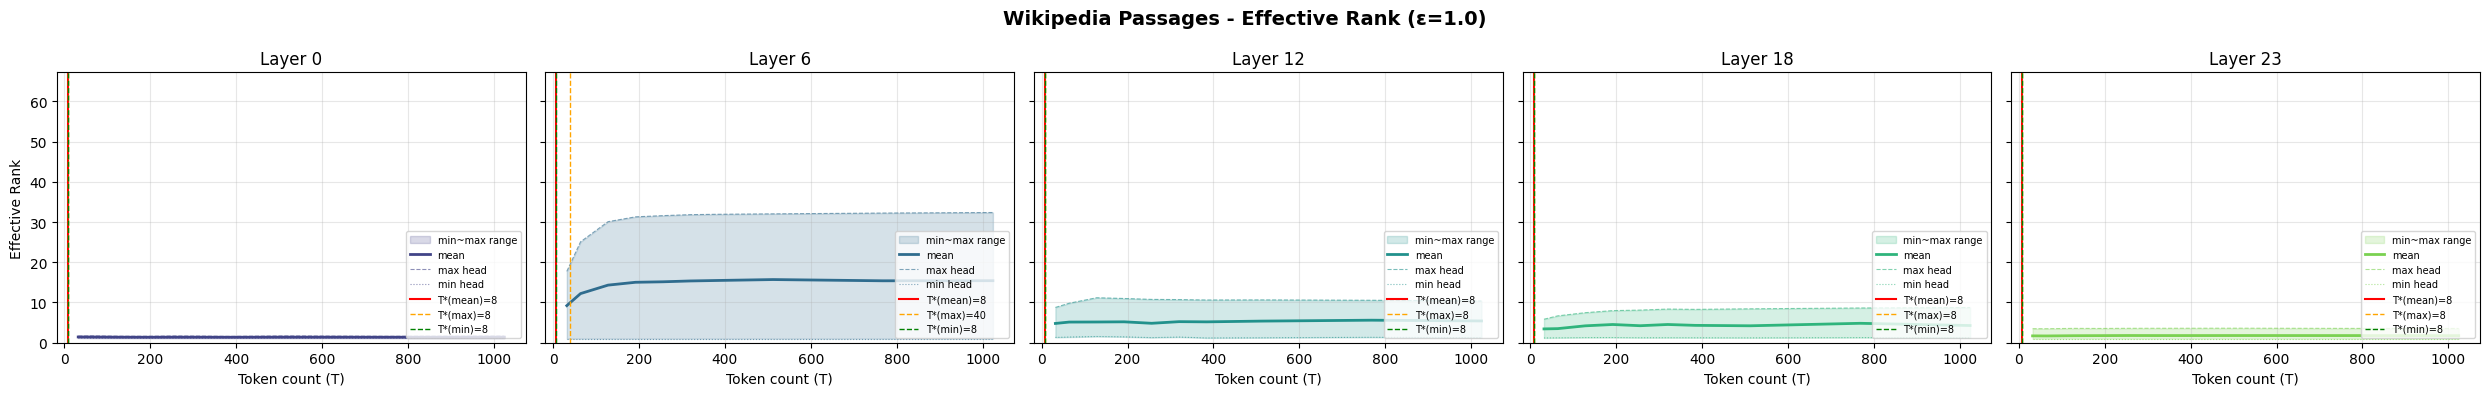

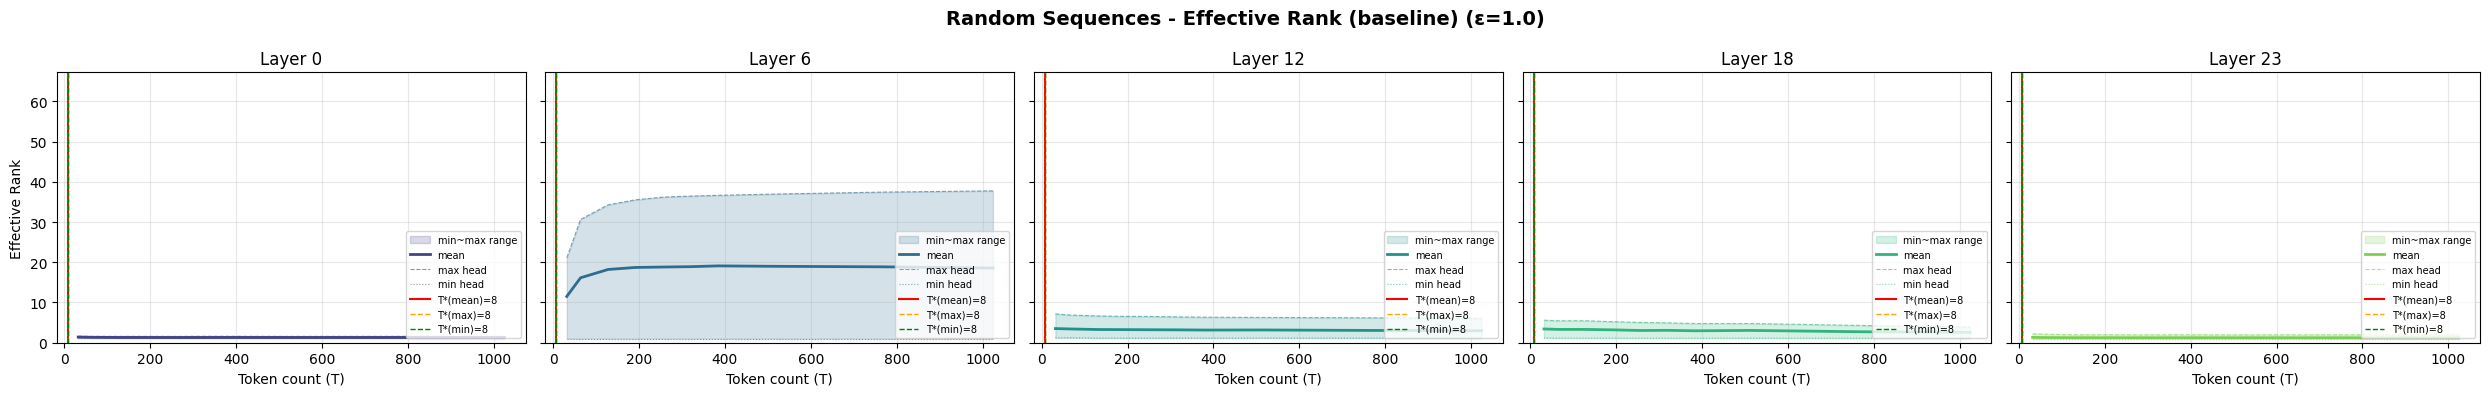

In [59]:
# Wikipedia
plot_rank_trajectories(
    wiki_results, wiki_sat,
    title="Wikipedia Passages - Effective Rank",
    epsilon=1.0,
    max_rank=min(HEADDIM, D_STATE)
)

# Random (baseline)
plot_rank_trajectories(
    rand_results, rand_sat,
    title="Random Sequences - Effective Rank (baseline)",
    epsilon=1.0,
    max_rank=min(HEADDIM, D_STATE)
)

In [63]:
def plot_layer_heatmap(ranks: dict, title: str, mode: str = 'mean'):
    """
    x: token position
    y: layer
    color: effective rank
    """
    data = ranks[mode]  # (n_layers, T)
    T_pos = np.array(ranks['T_range'])

    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(
        data,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        vmin=0,
        vmax=min(HEADDIM, D_STATE)
    )
    plt.colorbar(im, ax=ax, label='Effective Rank')

    # x축을 실제 token 수로
    n_ticks = 10
    tick_idx = np.linspace(0, len(T_pos)-1, n_ticks, dtype=int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([T_pos[i] for i in tick_idx])

    ax.set_xlabel('Token count (T)', fontsize=12)
    ax.set_ylabel('Layer', fontsize=12)
    ax.set_title(f'{title} - Effective Rank Heatmap ({mode})', fontsize=13)
    plt.tight_layout()
    plt.show()

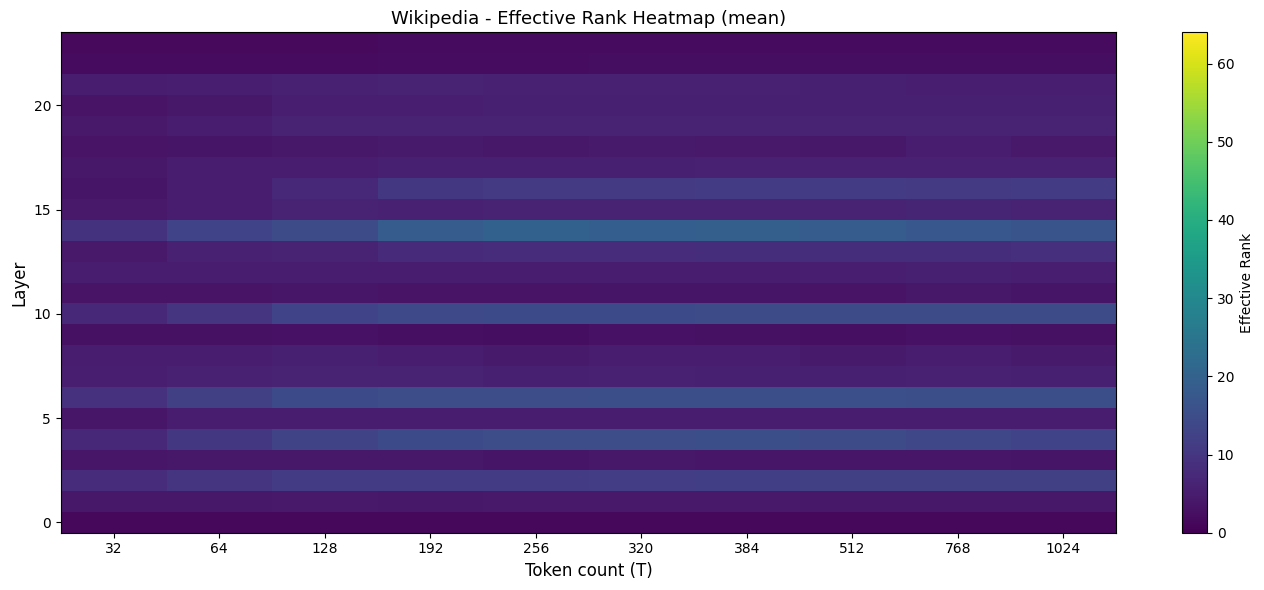

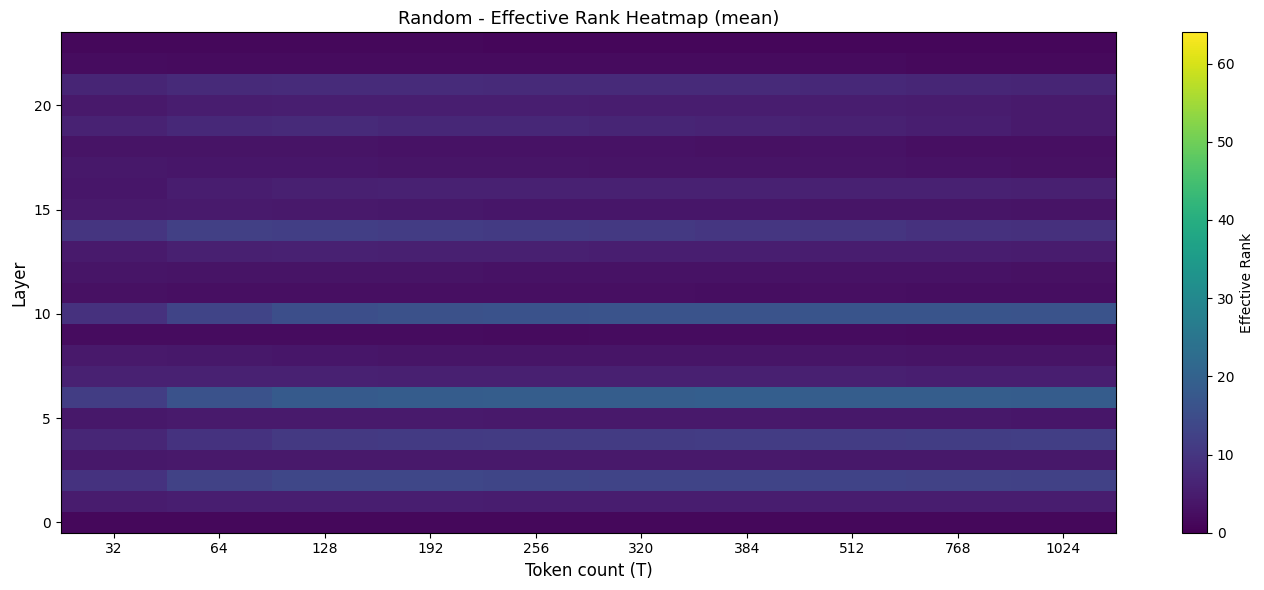

In [64]:
plot_layer_heatmap(wiki_results, "Wikipedia", mode='mean')
plot_layer_heatmap(rand_results, "Random",    mode='mean')

In [65]:
def plot_saturation_sensitivity(wiki_sat: dict, rand_sat: dict, epsilons: list):
    """
    epsilon sensitivity 분석:
    epsilon 값마다 T*_chunk_{mean/max/min} 비교
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, sat, label in zip(axes, [wiki_sat, rand_sat], ['Wikipedia', 'Random']):
        chunk_mean = [sat[e]['T*_chunk_mean'] for e in epsilons]
        chunk_max  = [sat[e]['T*_chunk_max']  for e in epsilons]
        chunk_min  = [sat[e]['T*_chunk_min']  for e in epsilons]

        x = range(len(epsilons))
        ax.plot(x, chunk_mean, 'o-', color='red',    linewidth=2, label='T*(mean head → mean layer)')
        ax.plot(x, chunk_max,  's--', color='orange', linewidth=1.5, label='T*(max head → mean layer)')
        ax.plot(x, chunk_min,  '^:',  color='green',  linewidth=1.5, label='T*(min head → mean layer)')

        ax.fill_between(x, chunk_min, chunk_max, alpha=0.1, color='gray')

        ax.set_xticks(x)
        ax.set_xticklabels([f'ε={e}' for e in epsilons])
        ax.set_ylabel('T* chunk boundary (tokens)')
        ax.set_title(f'{label} - Sensitivity to ε', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle('Saturation Point Sensitivity Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

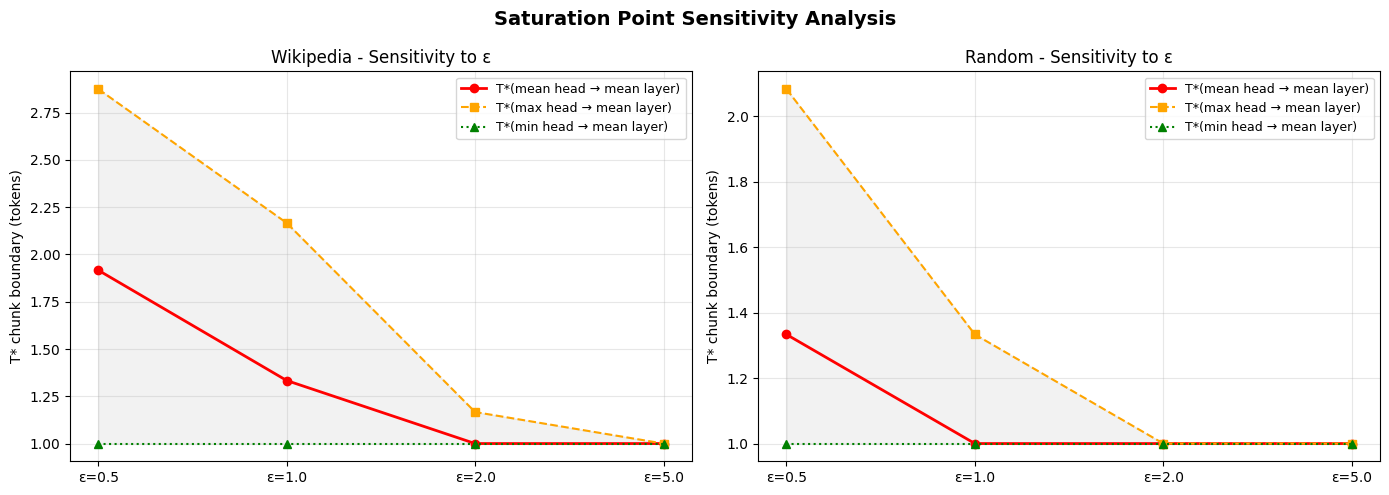

In [66]:
plot_saturation_sensitivity(wiki_sat, rand_sat, EPSILONS)

In [69]:
def plot_T_star_per_layer(wiki_sat: dict, rand_sat: dict, epsilon: float = 1.0):
    """
    layer별 T* 비교 (mean / max / min head 기준)
    Wiki vs Random 나란히
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sat, label in zip(axes, [wiki_sat, rand_sat], ['Wikipedia', 'Random']):
        r        = sat[epsilon]
        layers   = np.arange(N_LAYERS)
        t_mean   = r['T*_mean_per_layer'] * 8
        t_max    = r['T*_max_per_layer']  * 8
        t_min    = r['T*_min_per_layer']  * 8

        ax.plot(layers, t_mean, 'o-',  color='red',    linewidth=2,   label='mean head T*')
        ax.plot(layers, t_max,  's--', color='orange', linewidth=1.2, label='max head T*')
        ax.plot(layers, t_min,  '^:',  color='green',  linewidth=1.2, label='min head T*')
        ax.fill_between(layers, t_min, t_max, alpha=0.15, color='gray', label='min~max range')

        # chunk 경계 (전체 레이어 mean)
        ax.axhline(r['T*_chunk_mean'], color='red',    linestyle='-',  linewidth=1.5,
                   label=f"chunk boundary (mean)={r['T*_chunk_mean']:.0f}")
        ax.axhline(r['T*_chunk_max'],  color='orange', linestyle='--', linewidth=1.0,
                   label=f"chunk boundary (max)={r['T*_chunk_max']:.0f}")
        ax.axhline(r['T*_chunk_min'],  color='green',  linestyle='--', linewidth=1.0,
                   label=f"chunk boundary (min)={r['T*_chunk_min']:.0f}")

        ax.set_xlabel('Layer index', fontsize=11)
        ax.set_ylabel('Saturation token (T*)', fontsize=11)
        ax.set_title(f'{label} - T* per Layer (ε={epsilon})', fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle('Per-Layer Saturation Points', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

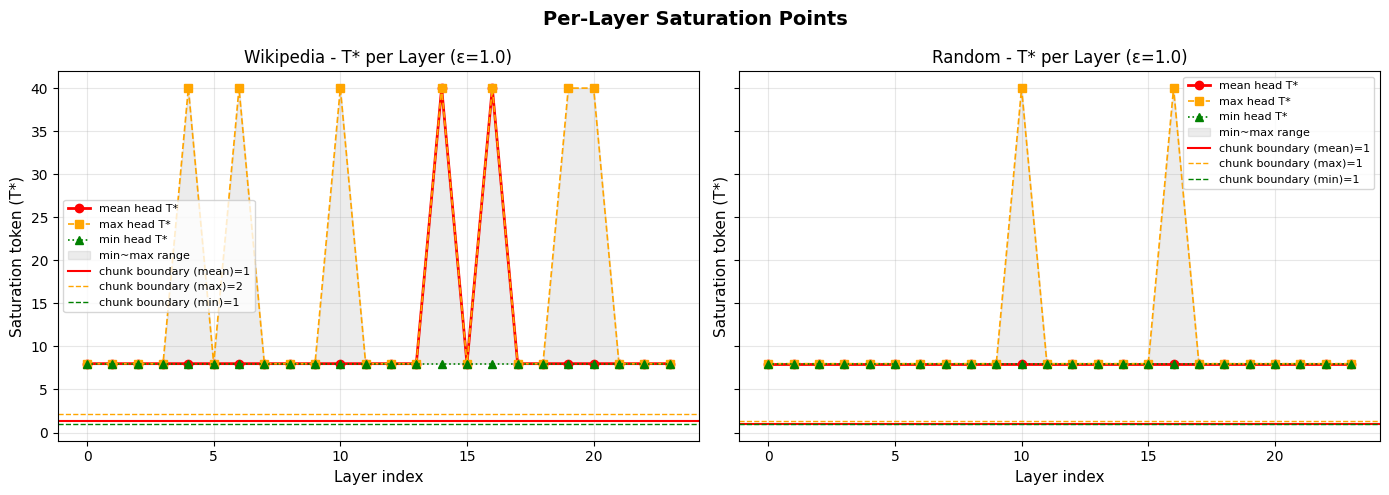

In [70]:
plot_T_star_per_layer(wiki_sat, rand_sat, epsilon=1.0)

## 11. 최종 결과 요약

In [71]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"Model    : {MODEL_NAME}")
print(f"d_model  : {cfg.d_model}")
print(f"d_state  : {D_STATE}")
print(f"headdim  : {HEADDIM}")
print(f"n_layers : {N_LAYERS}")
print(f"n_heads  : {N_HEADS}")
print(f"Max eff rank (theory): {min(HEADDIM, D_STATE)}")
print()

EPS = 1.0  # 메인 결과용 epsilon

print(f"[ε = {EPS}]")
print(f"{'':20} | {'T*_mean':>10} | {'T*_max':>10} | {'T*_min':>10}")
print("-" * 58)
print(f"{'Wikipedia chunk boundary':20} | "
      f"{wiki_sat[EPS]['T*_chunk_mean']:>10.1f} | "
      f"{wiki_sat[EPS]['T*_chunk_max']:>10.1f} | "
      f"{wiki_sat[EPS]['T*_chunk_min']:>10.1f}")
print(f"{'Random chunk boundary':20} | "
      f"{rand_sat[EPS]['T*_chunk_mean']:>10.1f} | "
      f"{rand_sat[EPS]['T*_chunk_max']:>10.1f} | "
      f"{rand_sat[EPS]['T*_chunk_min']:>10.1f}")
print()
print("→ Wikipedia의 T*_chunk_mean 이 RAG chunking 경계 추천값")
print(f"  Recommended chunk size: {wiki_sat[EPS]['T*_chunk_mean']:.0f} tokens")

FINAL RESULTS SUMMARY
Model    : state-spaces/mamba2-130m
d_model  : 768
d_state  : 128
headdim  : 64
n_layers : 24
n_heads  : 24
Max eff rank (theory): 64

[ε = 1.0]
                     |    T*_mean |     T*_max |     T*_min
----------------------------------------------------------
Wikipedia chunk boundary |        1.3 |        2.2 |        1.0
Random chunk boundary |        1.0 |        1.3 |        1.0

→ Wikipedia의 T*_chunk_mean 이 RAG chunking 경계 추천값
  Recommended chunk size: 1 tokens


## 12. 결과 저장

In [74]:
import json

results_to_save = {
    'model'       : MODEL_NAME,
    'config'      : {
        'd_model' : cfg.d_model,
        'd_state' : D_STATE,
        'headdim' : HEADDIM,
        'n_layers': N_LAYERS,
        'n_heads' : N_HEADS,
    },
    'wiki_saturation': {
        str(eps): {
            'T*_chunk_mean': float(wiki_sat[eps]['T*_chunk_mean']),
            'T*_chunk_max' : float(wiki_sat[eps]['T*_chunk_max']),
            'T*_chunk_min' : float(wiki_sat[eps]['T*_chunk_min']),
            'T*_mean_per_layer': wiki_sat[eps]['T*_mean_per_layer'].tolist(),
        }
        for eps in EPSILONS
    },
    'rand_saturation': {
        str(eps): {
            'T*_chunk_mean': float(rand_sat[eps]['T*_chunk_mean']),
            'T*_chunk_max' : float(rand_sat[eps]['T*_chunk_max']),
            'T*_chunk_min' : float(rand_sat[eps]['T*_chunk_min']),
        }
        for eps in EPSILONS
    },
}

with open('mamba2_rank_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

# numpy arrays도 저장
np.save('wiki_ranks_mean.npy', wiki_results['mean'])
np.save('wiki_ranks_max.npy',  wiki_results['max'])
np.save('wiki_ranks_min.npy',  wiki_results['min'])
np.save('rand_ranks_mean.npy', wiki_results['mean'])

print("Results saved: mamba2_rank_results.json")
print("Arrays saved : wiki_ranks_*.npy, rand_ranks_mean.npy")

Results saved: mamba2_rank_results.json
Arrays saved : wiki_ranks_*.npy, rand_ranks_mean.npy


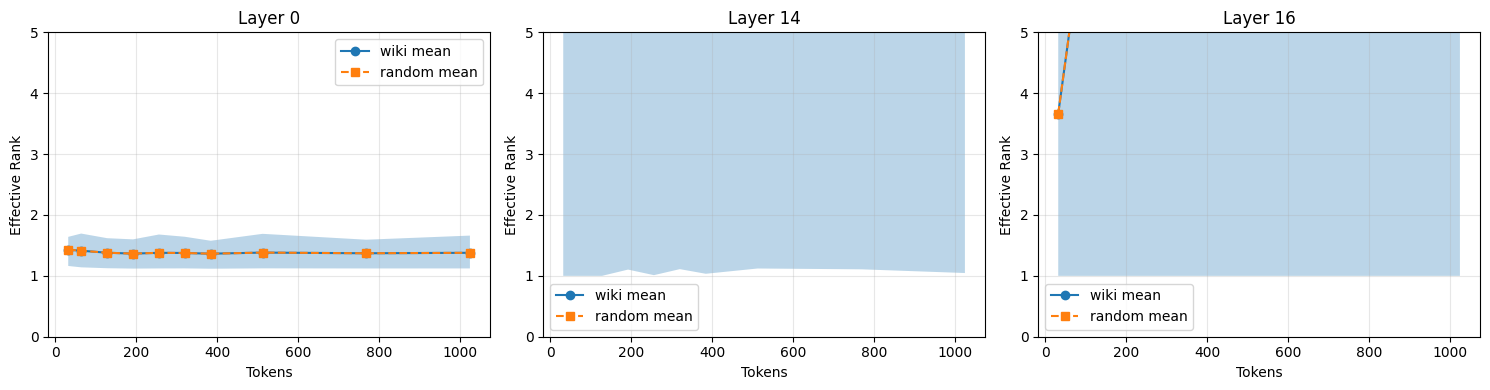

Wiki mean rank range: 1.364 ~ 19.813
Wiki max rank range:  1.576 ~ 36.384
Layer 14 curve: [ 9.46073209 12.81550148 14.82466231 18.5388966  19.8133657  19.05585074
 19.31873144 18.68403965 17.457876   16.69560834]
Layer 16 curve: [ 3.66380816  5.22681519  7.08789368 10.42570852 10.82539569 10.86211603
 11.40665071 11.30695314 10.99781663 11.02935792]


In [76]:
# 지금 당장 확인 가능한 것
# npy 파일 로드해서 실제 rank curve 모양 확인

import numpy as np
import matplotlib.pyplot as plt

wiki_mean = np.load('wiki_ranks_mean.npy')  # (n_layers, n_T)
wiki_max  = np.load('wiki_ranks_max.npy')
wiki_min  = np.load('wiki_ranks_min.npy')
rand_mean = np.load('rand_ranks_mean.npy')

T_RANGE = [32, 64, 128, 192, 256, 320, 384, 512, 768, 1024]

# layer 14 (T*=5~6으로 늦게 포화된 특이 레이어) 확인
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, layer in zip(axes, [0, 14, 16]):
    ax.plot(T_RANGE, wiki_mean[layer], 'o-', label='wiki mean')
    ax.fill_between(T_RANGE, wiki_min[layer], wiki_max[layer], alpha=0.3)
    ax.plot(T_RANGE, rand_mean[layer], 's--', label='random mean')
    ax.set_title(f'Layer {layer}')
    ax.set_xlabel('Tokens')
    ax.set_ylabel('Effective Rank')
    ax.set_ylim(0, 5)  # rank가 1~3이니까 확대해서 보기
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 전체 rank 값 범위 확인
print(f"Wiki mean rank range: {wiki_mean.min():.3f} ~ {wiki_mean.max():.3f}")
print(f"Wiki max rank range:  {wiki_max.min():.3f} ~ {wiki_max.max():.3f}")
print(f"Layer 14 curve: {wiki_mean[14]}")
print(f"Layer 16 curve: {wiki_mean[16]}")


## 13. Next Steps

이 노트북으로 확인할 것:

1. **T*가 epsilon에 robust한가?** → sensitivity 분석 결과에서 확인
2. **Wiki vs Random T* 차이가 있는가?** → 도메인별 adaptive chunking 근거
3. **Layer depth에 따라 T*가 단조증가/감소하는가?** → early/late layer 역할 분석
4. **max-min band width가 작은가?** → head간 specialization 여부

확인 후 → Step 2: T* 크기로 chunking했을 때 QA 성능 비교

In [78]:
for layer_idx in [0, 6, 12, 23]:
    A_log = model.backbone.layers[layer_idx].mixer.A_log.detach().cpu()
    A = -torch.exp(A_log)
    print(f"\nLayer {layer_idx}:")
    print(f"  A range: [{A.min():.4f}, {A.max():.4f}]")
    print(f"  50 step decay: {torch.exp(50*A).mean():.6f}")
    print(f"  200 step decay: {torch.exp(200*A).mean():.6f}")
    print(f"  1000 step decay: {torch.exp(1000*A).mean():.6f}")


Layer 0:
  A range: [-5.0636, -0.2707]
  50 step decay: 0.000000
  200 step decay: 0.000000
  1000 step decay: 0.000000

Layer 6:
  A range: [-3980.1011, -0.0007]
  50 step decay: 0.364528
  200 step decay: 0.242252
  1000 step decay: 0.066669

Layer 12:
  A range: [-0.7236, -0.0296]
  50 step decay: 0.044285
  200 step decay: 0.000160
  1000 step decay: 0.000000

Layer 23:
  A range: [-1018.1894, -4.0291]
  50 step decay: 0.000000
  200 step decay: 0.000000
  1000 step decay: 0.000000


In [80]:
for layer_idx in [0, 6, 12, 23]:
    A_log  = model.backbone.layers[layer_idx].mixer.A_log.detach().cpu()
    dt_bias = model.backbone.layers[layer_idx].mixer.dt_bias.detach().cpu()
    
    A      = -torch.exp(A_log)           # continuous-time A
    dt     = torch.nn.functional.softplus(dt_bias)  # 실제 dt
    
    # 실제 discrete-time decay
    A_disc = torch.exp(A * dt)           # exp(-exp(A_log) * dt)
    
    print(f"\nLayer {layer_idx}:")
    print(f"  A_log range : [{A_log.min():.4f}, {A_log.max():.4f}]")
    print(f"  dt range    : [{dt.min():.6f}, {dt.max():.6f}]")
    print(f"  A_disc range: [{A_disc.min():.6f}, {A_disc.max():.6f}]")
    print(f"  50  step decay (mean): {(A_disc**50).mean():.6f}")
    print(f"  200 step decay (mean): {(A_disc**200).mean():.6f}")
    print(f"  1000 step decay (mean): {(A_disc**1000).mean():.6f}")


Layer 0:
  A_log range : [-1.3066, 1.6221]
  dt range    : [0.034232, 0.101330]
  A_disc range: [0.840854, 0.976258]
  50  step decay (mean): 0.257007
  200 step decay (mean): 0.005354
  1000 step decay (mean): 0.000000

Layer 6:
  A_log range : [-7.2109, 8.2891]
  dt range    : [0.008956, 3.196080]
  A_disc range: [0.000000, 0.999802]
  50  step decay (mean): 0.533481
  200 step decay (mean): 0.358698
  1000 step decay (mean): 0.176730

Layer 12:
  A_log range : [-3.5195, -0.3235]
  dt range    : [0.119900, 3.348277]
  A_disc range: [0.247698, 0.996456]
  50  step decay (mean): 0.048734
  200 step decay (mean): 0.020661
  1000 step decay (mean): 0.001196

Layer 23:
  A_log range : [1.3936, 6.9258]
  dt range    : [0.002143, 0.637074]
  A_disc range: [0.000000, 0.977847]
  50  step decay (mean): 0.054189
  200 step decay (mean): 0.000818
  1000 step decay (mean): 0.000000


In [81]:
test_input = random_passages[0]

print("=== Layer 6, head with max A_disc (slow decay) ===")
for T in [32, 64, 128, 192, 248, 252, 256, 260, 320, 512, 768, 1024]:
    states = get_ssm_states(model, test_input[:, :T], device)
    r = effective_rank(states[6][0])
    print(f"T={T:5d}: rank={r:.4f}")

=== Layer 6, head with max A_disc (slow decay) ===
T=   32: rank=19.5656
T=   64: rank=28.6106
T=  128: rank=33.6146
T=  192: rank=35.4013
T=  248: rank=36.3597
T=  252: rank=36.4847
T=  256: rank=36.5722
T=  260: rank=36.6263
T=  320: rank=36.5112
T=  512: rank=36.5152
T=  768: rank=36.0197
T= 1024: rank=35.5566


In [83]:
# layer 6 전체 head별 rank 확인
states = get_ssm_states(model, test_input[:, :256], device)
state_6 = states[6]  # (24, 64, 128)

for h in range(24):
    r = effective_rank(state_6[h])
    A_log_6 = model.backbone.layers[6].mixer.A_log.detach().cpu()
    dt_6 = torch.nn.functional.softplus(
        model.backbone.layers[6].mixer.dt_bias.detach().cpu()
    )
    A_disc_h = torch.exp(-torch.exp(A_log_6[h]) * dt_6[h])
    print(f"head {h:2d}: rank={r:.3f}  A_disc={A_disc_h:.6f}")

head  0: rank=36.572  A_disc=0.998774
head  1: rank=9.778  A_disc=0.998556
head  2: rank=13.489  A_disc=0.963783
head  3: rank=34.051  A_disc=0.990405
head  4: rank=34.732  A_disc=0.999554
head  5: rank=33.413  A_disc=0.999711
head  6: rank=4.140  A_disc=0.707037
head  7: rank=8.278  A_disc=0.982927
head  8: rank=35.447  A_disc=0.999802
head  9: rank=1.000  A_disc=0.000000
head 10: rank=32.294  A_disc=0.999398
head 11: rank=20.057  A_disc=0.988834
head 12: rank=34.891  A_disc=0.999143
head 13: rank=1.362  A_disc=0.736281
head 14: rank=31.622  A_disc=0.998739
head 15: rank=9.375  A_disc=0.914448
head 16: rank=20.173  A_disc=0.982011
head 17: rank=8.071  A_disc=0.973212
head 18: rank=1.245  A_disc=0.718684
head 19: rank=6.885  A_disc=0.990875
head 20: rank=9.936  A_disc=0.973061
head 21: rank=30.930  A_disc=0.998380
head 22: rank=14.730  A_disc=0.997015
head 23: rank=2.876  A_disc=0.726789


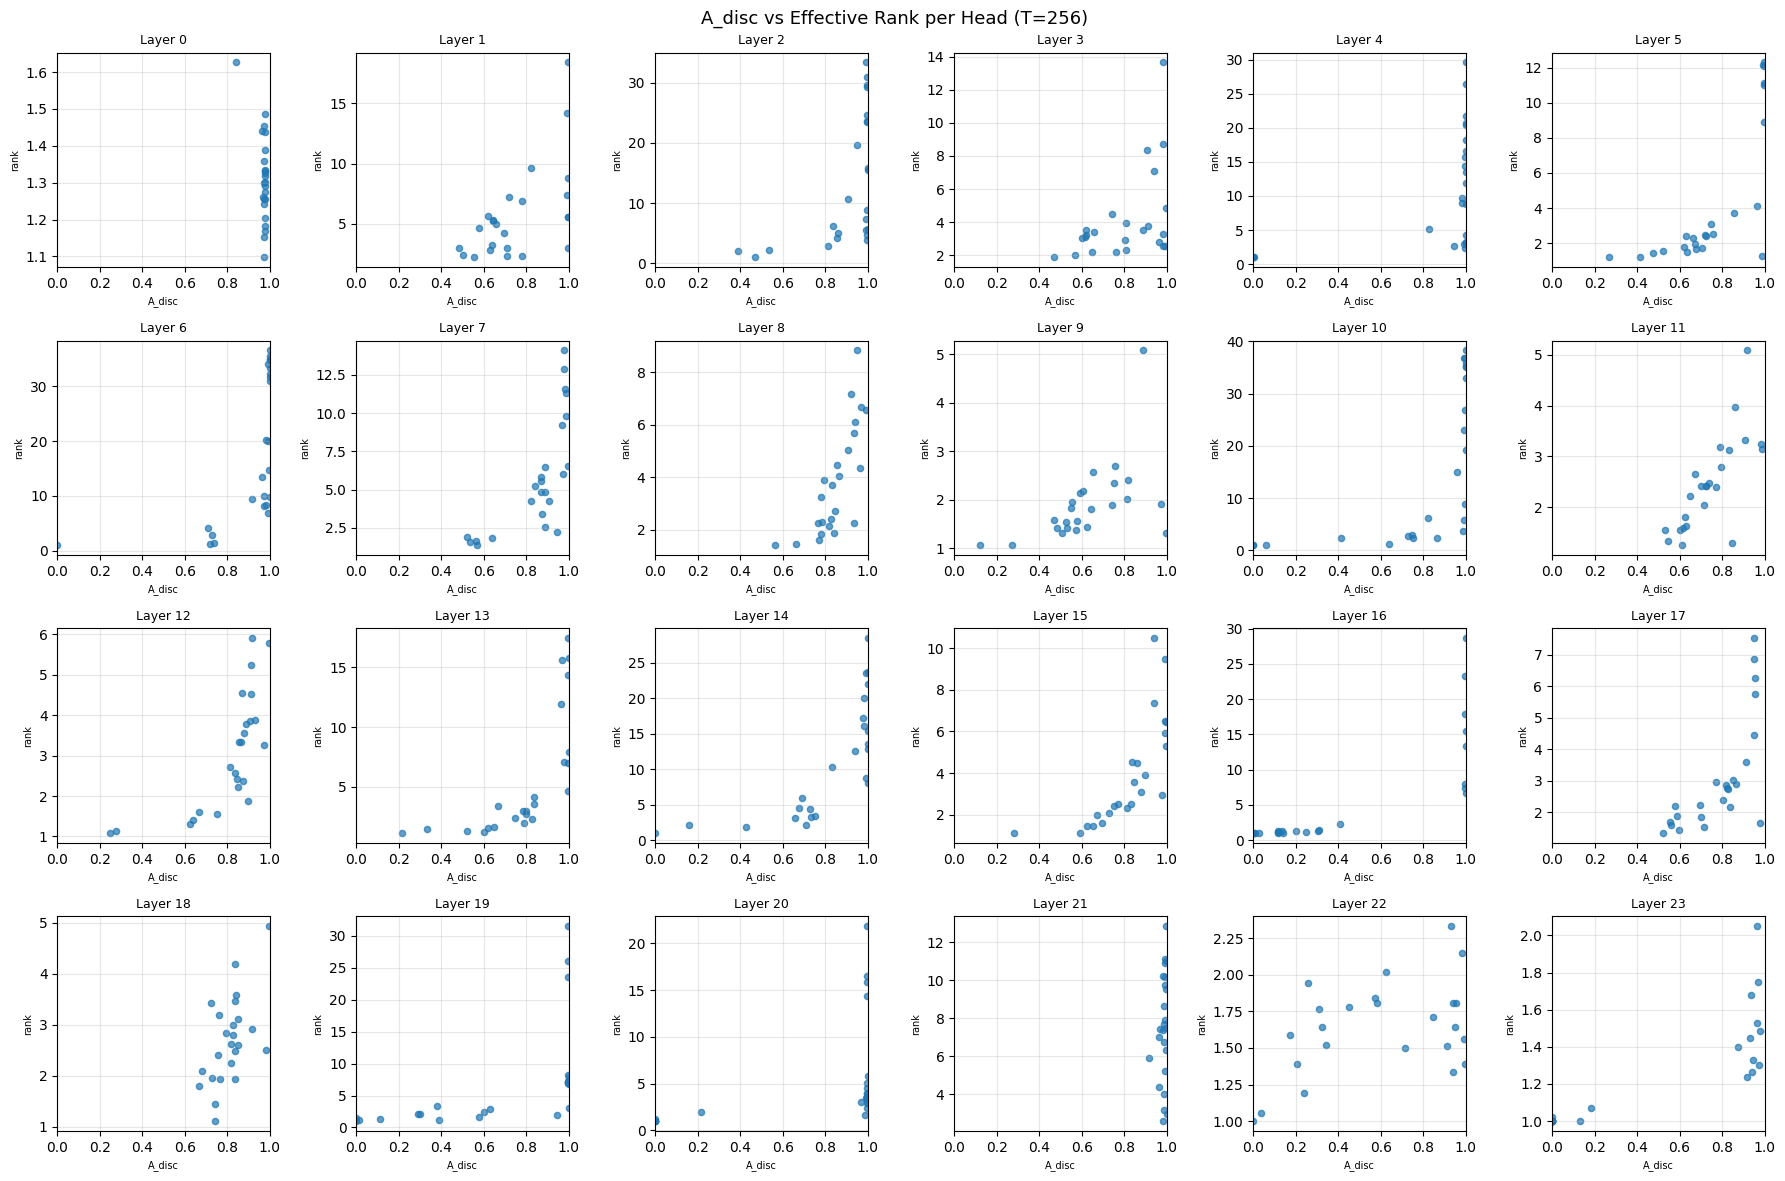

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# 전체 layer에 대해 A_disc vs rank scatter
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

states_256 = get_ssm_states(model, test_input[:, :256], device)

for layer_idx in range(24):
    A_log = model.backbone.layers[layer_idx].mixer.A_log.detach().cpu()
    dt    = torch.nn.functional.softplus(
                model.backbone.layers[layer_idx].mixer.dt_bias.detach().cpu())
    A_disc = torch.exp(-torch.exp(A_log) * dt).numpy()
    
    ranks = [effective_rank(states_256[layer_idx][h]) for h in range(N_HEADS)]
    
    axes[layer_idx].scatter(A_disc, ranks, s=20, alpha=0.7)
    axes[layer_idx].set_title(f'Layer {layer_idx}', fontsize=9)
    axes[layer_idx].set_xlabel('A_disc', fontsize=7)
    axes[layer_idx].set_ylabel('rank', fontsize=7)
    axes[layer_idx].set_xlim(0, 1)
    axes[layer_idx].grid(alpha=0.3)

plt.suptitle('A_disc vs Effective Rank per Head (T=256)', fontsize=13)
plt.tight_layout()
plt.savefig('A_disc_vs_rank.png', dpi=150)
plt.show()


In [88]:
# 같은 토픽 vs 다른 토픽 문서의 Type A state cosine similarity 비교
from sklearn.metrics.pairwise import cosine_similarity

def extract_type_a_state_vector(model, text, tokenizer, device, slow_heads):
    """Type A head state만 추출해서 flatten → 벡터화"""
    ids    = tokenizer.encode(text, return_tensors='pt')[:, :512]
    states = get_ssm_states(model, ids, device)
    
    # layer 6의 slow head만
    vecs = []
    for h in slow_heads:
        vecs.append(states[6][h].flatten().numpy())
    return np.concatenate(vecs)

# 같은 토픽 (AI 관련 텍스트 3개)
# 다른 토픽 (스포츠, 요리, 음악 텍스트 각 1개)
# cosine similarity matrix 그려보기